In [43]:
import numpy as np
import matplotlib.pyplot as plt
import cProfile, pstats
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [44]:
def mandelbrot_naive(rows, cols, max_iter=100):
    x = np.linspace(-2, 1, cols)
    y = np.linspace(-1.5, 1.5, rows)
    screen = x + y[:, None]*1j  

    iter_count = np.zeros((rows, cols), dtype=np.int16)

    for i in range(rows):
        for j in range(cols):
            z = 0 + 0j
            for k in range(max_iter):
                z = z**2 + screen[i, j]
                if abs(z) > 2:
                    break
            iter_count[i, j] = k 

    return iter_count

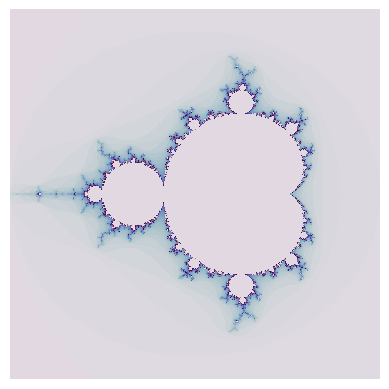

In [45]:
if __name__ == "__main__":
    rows, cols = 1000, 1000
    mandelbrot = mandelbrot_naive(rows, cols)

    plt.imshow(mandelbrot, cmap='twilight', interpolation='nearest')
    plt.axis('off')
    plt.show()

In [46]:
def mandelbrot_numpy(rows, cols, max_iter=50):
    x = np.linspace(-2, 1, cols)
    y = np.linspace(-1.5, 1.5, rows)
    C = x + y[:, None] * 1j

    Z = np.zeros_like(C, dtype=np.complex128)
    iter_count = np.zeros(C.shape, dtype=np.int16)

    mask = np.ones(C.shape, dtype=bool)
    t_vector = 0

    for k in range(max_iter):
        Z[mask] = Z[mask]**2 + C[mask]

        escaped = np.abs(Z) > 2

        newly_escaped = escaped & mask
        iter_count[newly_escaped] = k

        mask &= ~escaped

        if not mask.any():
            break
    return iter_count

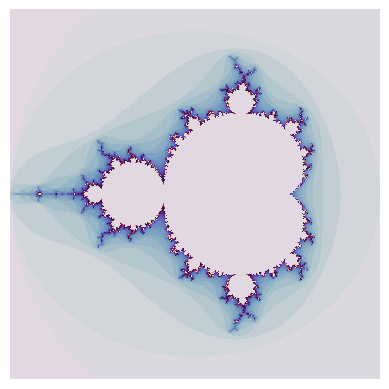

In [47]:
if __name__ == "__main__":
    rows, cols = 1000, 1000
    mandelbrot = mandelbrot_numpy(rows, cols)

    plt.imshow(mandelbrot, cmap='twilight', interpolation='nearest')
    plt.axis('off')
    plt.show()

In [48]:
cProfile.run("mandelbrot_naive(1000,1000,100)" ,"naive_profile.prof")

stats = pstats.Stats("naive_profile.prof")
stats.sort_stats("cumulative")
stats.print_stats()

Wed Mar  4 17:55:25 2026    naive_profile.prof

         20943329 function calls in 16.624 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   16.624   16.624 {built-in method builtins.exec}
        1    0.001    0.001   16.624   16.624 <string>:1(<module>)
        1   14.274   14.274   16.624   16.624 C:\Users\Aran\AppData\Local\Temp\ipykernel_6748\4158151397.py:1(mandelbrot_naive)
 20943298    2.349    0.000    2.349    0.000 {built-in method builtins.abs}
        2    0.000    0.000    0.000    0.000 c:\Users\Aran\miniforge3\envs\myenv\Lib\site-packages\numpy\_core\function_base.py:27(linspace)
        1    0.000    0.000    0.000    0.000 {built-in method numpy.zeros}
        2    0.000    0.000    0.000    0.000 {built-in method numpy.arange}
        2    0.000    0.000    0.000    0.000 c:\Users\Aran\miniforge3\envs\myenv\Lib\site-packages\numpy\_core\numeric.py:1975(isscalar)
        2    

In [49]:
cProfile.run("mandelbrot_numpy(1000,1000,100)" ,"numpy_profile.prof")

stats = pstats.Stats("numpy_profile.prof")
stats.sort_stats("cumulative")
stats.print_stats()

Wed Mar  4 17:55:26 2026    numpy_profile.prof

         339 function calls in 0.905 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.905    0.905 {built-in method builtins.exec}
        1    0.002    0.002    0.905    0.905 <string>:1(<module>)
        1    0.895    0.895    0.903    0.903 C:\Users\Aran\AppData\Local\Temp\ipykernel_6748\50769478.py:1(mandelbrot_numpy)
        1    0.005    0.005    0.005    0.005 c:\Users\Aran\miniforge3\envs\myenv\Lib\site-packages\numpy\_core\numeric.py:97(zeros_like)
      100    0.001    0.000    0.003    0.000 {method 'any' of 'numpy.ndarray' objects}
      100    0.000    0.000    0.002    0.000 c:\Users\Aran\miniforge3\envs\myenv\Lib\site-packages\numpy\_core\_methods.py:55(_any)
      100    0.002    0.000    0.002    0.000 {method 'reduce' of 'numpy.ufunc' objects}
        2    0.000    0.000    0.000    0.000 c:\Users\Aran\miniforge3\envs\myenv\L

## M1

**1. Which function takes most total time?** <br>
<br>
The function with the most total time is the naive implementation with loops<br>
<br>
**2. Are there functions called surprisingly many times?** <br>
<br>
In the implementation without numpy there are a lot of calls to built-in methods, in this case it has checked for the magnitude of values millions of times.<br>
<br>
**3. How does NumPy profile compare to naive?** <br>
<br>
The operations are no longer run by python in the case of the numpy implementation, therefore insterad of seeing millions of operations usingbuilt-in functions from python we observe numpy C functions being called an equal ammount to our loops.<br>
<br>
**4. Where does NumPy spend its time?** <br>
<br>
Almost all the runtime happens inside C-level numpy code.<br>
<br>

In [50]:
%lprun -f mandelbrot_naive mandelbrot_naive(1000, 1000, 50)


Timer unit: 1e-07 s

Total time: 16.9945 s
File: C:\Users\Aran\AppData\Local\Temp\ipykernel_6748\4158151397.py
Function: mandelbrot_naive at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def mandelbrot_naive(rows, cols, max_iter=100):
     2         1       1076.0   1076.0      0.0      x = np.linspace(-2, 1, cols)
     3         1        376.0    376.0      0.0      y = np.linspace(-1.5, 1.5, rows)
     4         1      56154.0  56154.0      0.0      screen = x + y[:, None]*1j  
     5                                           
     6         1        323.0    323.0      0.0      iter_count = np.zeros((rows, cols), dtype=np.int16)
     7                                           
     8      1001       2447.0      2.4      0.0      for i in range(rows):
     9   1001000    1858319.0      1.9      1.1          for j in range(cols):
    10   1000000    1549186.0      1.5      0.9              z = 0 + 0j
    11  12

In [51]:
%lprun -f mandelbrot_numpy mandelbrot_numpy(1000, 1000, 50)

Timer unit: 1e-07 s

Total time: 0.486041 s
File: C:\Users\Aran\AppData\Local\Temp\ipykernel_6748\50769478.py
Function: mandelbrot_numpy at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def mandelbrot_numpy(rows, cols, max_iter=50):
     2         1        877.0    877.0      0.0      x = np.linspace(-2, 1, cols)
     3         1        218.0    218.0      0.0      y = np.linspace(-1.5, 1.5, rows)
     4         1      53176.0  53176.0      1.1      C = x + y[:, None] * 1j
     5                                           
     6         1      41032.0  41032.0      0.8      Z = np.zeros_like(C, dtype=np.complex128)
     7         1        343.0    343.0      0.0      iter_count = np.zeros(C.shape, dtype=np.int16)
     8                                           
     9         1       1025.0   1025.0      0.0      mask = np.ones(C.shape, dtype=bool)
    10         1          3.0      3.0      0.0      t_vector = 

## M2

1. cProfile on naive vs NumPy: How many functions appear in each profile? What does
this difference tell you about where the work actually happens?<br>
<br>
The work in the naive implementation happens at python level, where the profiler is able to see the functions as built-in functions. The numpy implementation does not see the millions of element wise operations as they happen in C, below python.<br>

**NAIVE PROFILER**
```
Mon Mar  2 18:16:43 2026    naive_profile.prof

         20943329 function calls in 16.691 seconds

   Ordered by: cumulative time

    ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   16.691   16.691 {built-in method builtins.exec}
        1    0.001    0.001   16.691   16.691 <string>:1(<module>)
        1   14.029   14.029   16.690   16.690 C:\Users\Aran\AppData\Local\Temp\ipykernel_27848\774291089.py:1(mandelbrot_naive)
        20943298    2.661    0.000    2.661    0.000 {built-in method builtins.abs}
```
**NUMPY PROFILER**
```
    Mon Mar  2 18:23:41 2026    numpy_profile.prof

        399 function calls in 1.063 seconds

    Ordered by: cumulative time

    ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    1.063    1.063 {built-in method builtins.exec}
        1    0.002    0.002    1.063    1.063 <string>:1(<module>)
        1    1.050    1.050    1.061    1.061 C:\Users\Aran\AppData\Local\Temp\ipykernel_27848\414567218.py:1(mandelbrot_numpy)
        1    0.005    0.005    0.005    0.005 c:\Python311\Lib\site-packages\numpy\_core\numeric.py:64(zeros_like)
        100    0.001    0.000    0.005    0.000 {method 'any' of 'numpy.ndarray' objects}
        100    0.000    0.000    0.004    0.000 c:\Python311\Lib\site-packages\numpy\_core\_methods.py:58(_any)
        100    0.004    0.000    0.004    0.000 {method 'reduce' of 'numpy.ufunc' objects}
        1    0.000    0.000    0.001    0.001 {built-in method builtins.print}
```
2. line profiler on naive: Which lines dominate runtime? What fraction of total time is
spent in the inner loop?<br>
<br>
The lines that dominate runtime are z = z**2 + screen[i, j] and if abs(z) > 2, these lines account for 79% of the total runtime, with an aproximate grand total of 95% of the time inside of the loop. <br>
```
    Line #    Hits        Time      Per Hit   % Time                Line Contents
    ==================================================================================
        11  12456060   22057977.0      1.8     15.0              for k in range(max_iter):
        12  12279956   70972627.0      5.8     48.2                 z = z**2 + screen[i, j]
        13  12279956   45454329.0      3.7     30.9                 if abs(z) > 2:
        14    823896    1260654.0      1.5      0.9                     break
```
3. Based on your profiling results: why is NumPy faster than naive Python?<br>
<br>
Python has to realize millions of operations whereas numpy optimizes these into a few hundred C-level optimized array operations.<br>
<br>
4. What would you need to change to make the naive version faster?<br>
<br>
Some operations can be improved by breaking them down into operations that are easyer to calculate by python such as changing Z**2 to Z*Z.<br>
<br>

In [52]:
from numba import njit

@njit
def mandelbrot_naive_numba(rows, cols, max_iter=50):
    x = np.linspace(-2, 1, cols)
    y = np.linspace(-1.5, 1.5, rows)
    screen = x + y[:, None]*1j  
    iter_count = np.zeros((rows, cols), dtype=np.int16)

    for i in range(rows):
        for j in range(cols):
            z = 0j
            for k in range(max_iter):
                z = z*z + screen[i, j]
                if z.real * z.real + z.imag * z.imag > 4.0:
                    break
            iter_count[i, j] = k 

    return iter_count

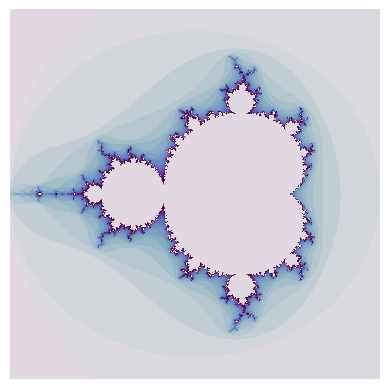

In [ ]:
if __name__ == "__main__":
    rows, cols = 1024, 1024
    mandelbrot = mandelbrot_naive_numba(rows, cols)

    plt.imshow(mandelbrot, cmap='twilight', interpolation='nearest')
    plt.axis('off')
    plt.show()

In [ ]:
import time , statistics
def bench (fn, *args, runs=5):
    fn(*args) # extra warm -up
    times = []
    for _ in range (runs):
        t0 = time.perf_counter()
        fn(*args)
        times.append(time.perf_counter() - t0)
    return statistics.median(times)

In [ ]:
args = (1024, 1024, 100)
t_naive = bench(mandelbrot_naive, *args)
t_numpy = bench(mandelbrot_numpy, *args)
t_numba = bench(mandelbrot_naive_numba, *args)
print(f"Naive: {t_naive:.3f}s")
print(f"NumPy: {t_numpy:.3f}s ({t_naive / t_numpy:.1f}x)")
print(f"Numba: {t_numba:.3f}s ({t_naive / t_numba:.1f}x)")

Naive: 10.825s
NumPy: 0.982s (11.0x)
Numba: 0.063s (172.6x)


# M3

```
Naive: 10.839s
NumPy: 1.010s (10.7x)
Numba: 0.060s (181.6x)
```

In [59]:
@njit
def mandelbrot_numba_dtype(rows, cols, max_iter=50, dtype=np.float64):
    x = np.linspace(-2, 1, cols).astype(dtype)
    y = np.linspace(-1.5, 1.5, rows).astype(dtype)
    screen = x + y[:, None]*1j  
    iter_count = np.zeros((rows, cols), dtype=dtype)

    for i in range(rows):
        for j in range(cols):
            z = 0j
            for k in range(max_iter):
                z = z*z + screen[i, j]
                if z.real * z.real + z.imag * z.imag > 4.0:
                    break
            iter_count[i, j] = k 

    return iter_count

In [84]:
if __name__ == "__main__":
    rows, cols = 1024, 1024
    for dtype in [np.float32, np.float64]:
        t0 = time.perf_counter()
        mandelbrot_numba_dtype(1024, 1024, 100, dtype = dtype)
        print(f"{dtype.__name__}: {time.perf_counter()-t0:.3f}s")

float32: 0.064s
float64: 0.064s


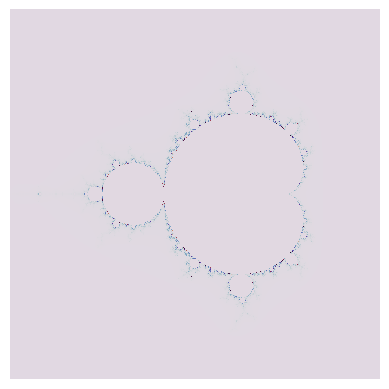

In [ ]:
if __name__ == "__main__":
    rows, cols = 2048, 2048
    mandelbrot = mandelbrot_numba_dtype(rows, cols, 10000, dtype = np.float32)

    plt.imshow(mandelbrot, cmap='twilight', interpolation='nearest')
    plt.axis('off')
    plt.show()

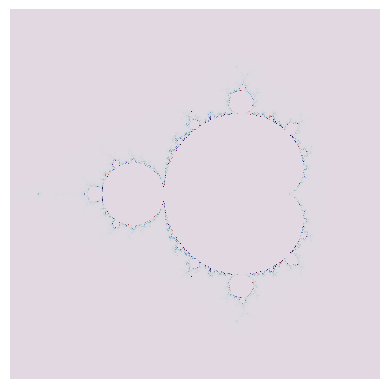

In [ ]:
if __name__ == "__main__":
    rows, cols = 2048, 2048
    mandelbrot = mandelbrot_numba_dtype(rows, cols, 10000, dtype = np.float64)

    plt.imshow(mandelbrot, cmap='twilight', interpolation='nearest')
    plt.axis('off')
    plt.show()

▶ Speed: Does float32 actually run faster than float64 on your hardware? By how much?<br>
They take the same time:
float32: 0.065s
float64: 0.065s

▶ float16: Try it with NumPy — is it faster than float32? (It may not be, since NumPy
promotes to float32 internally.) Numba may refuse to compile float16 — if so, skip it and
note why.
▶ Visual quality: Zoom in on a detailed region of the Mandelbrot set. Can you see
artefacts with float16? What about float32?
▶ Recommendation: Based on what you observe, which precision would you choose for
production use, and why?

float32: 0.065s
float64: 0.065s